In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv("Pharma_Industry.csv")

df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(500, 6)

Column Names:
Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None

Missing Values:
Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (B

Drug Response
1    260
0    240
Name: count, dtype: int64


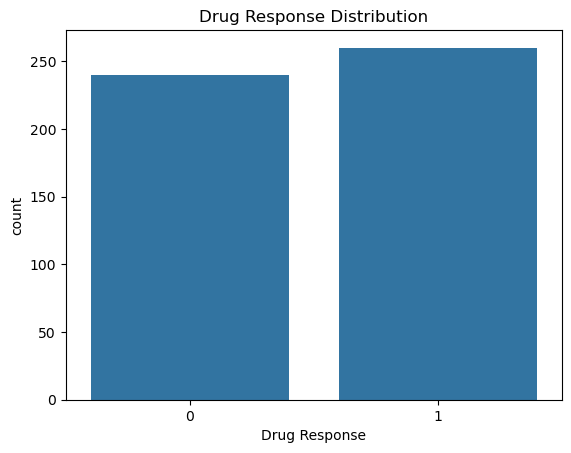

In [4]:
print(df['Drug Response'].value_counts())

sns.countplot(x='Drug Response', data=df)
plt.title("Drug Response Distribution")
plt.show()

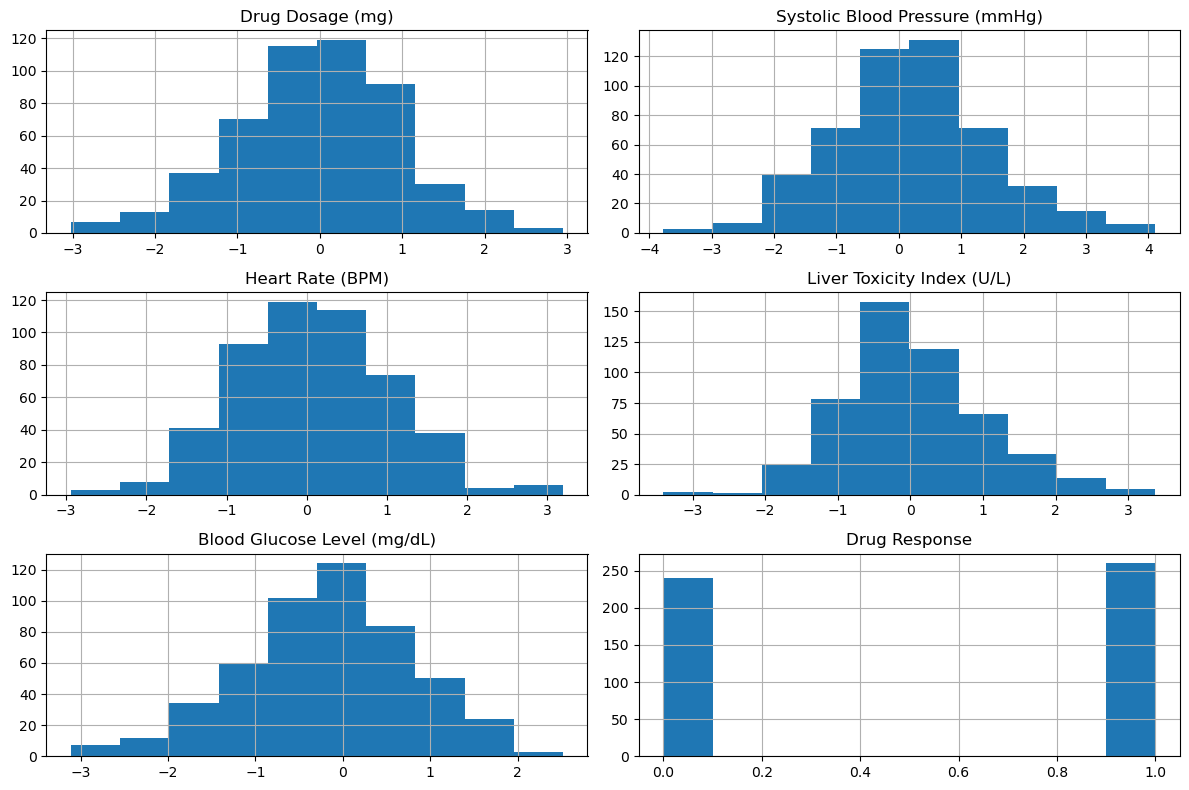

In [5]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

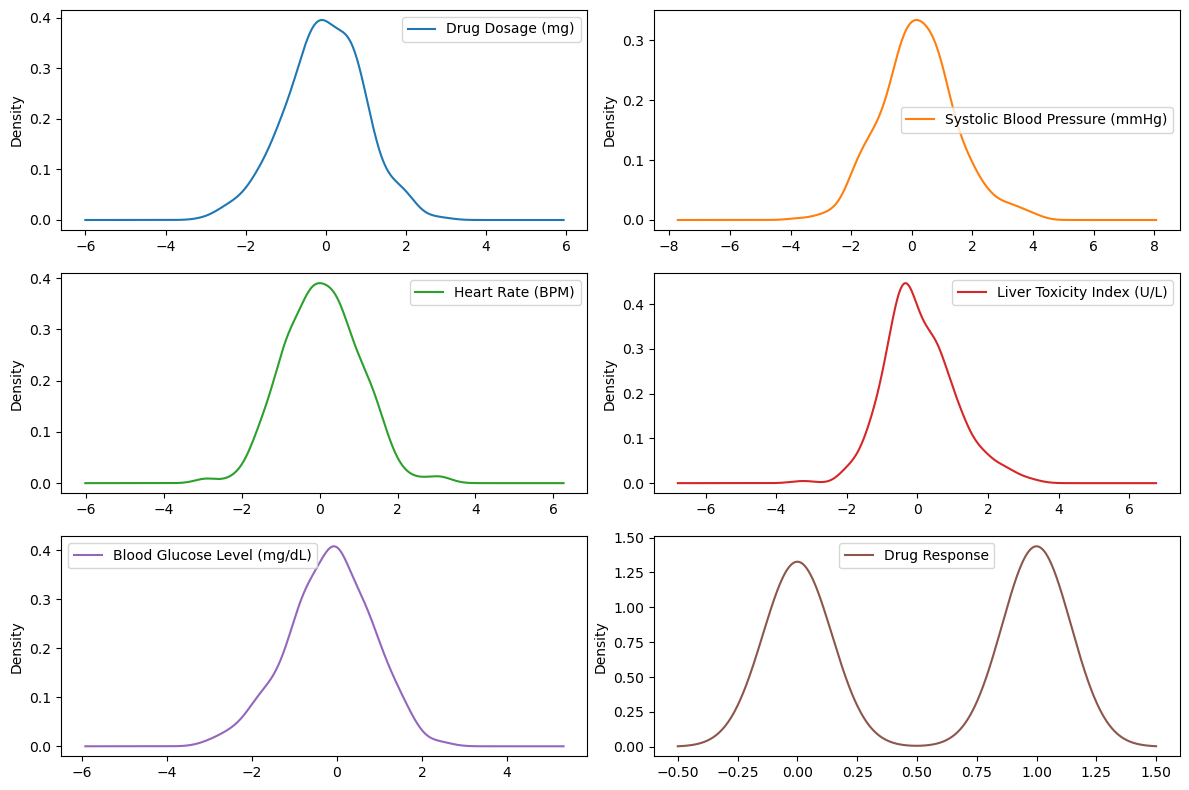

In [6]:
df.plot(kind='density',
        subplots=True,
        layout=(3,2),
        figsize=(12,8),
        sharex=False)

plt.tight_layout()
plt.show()

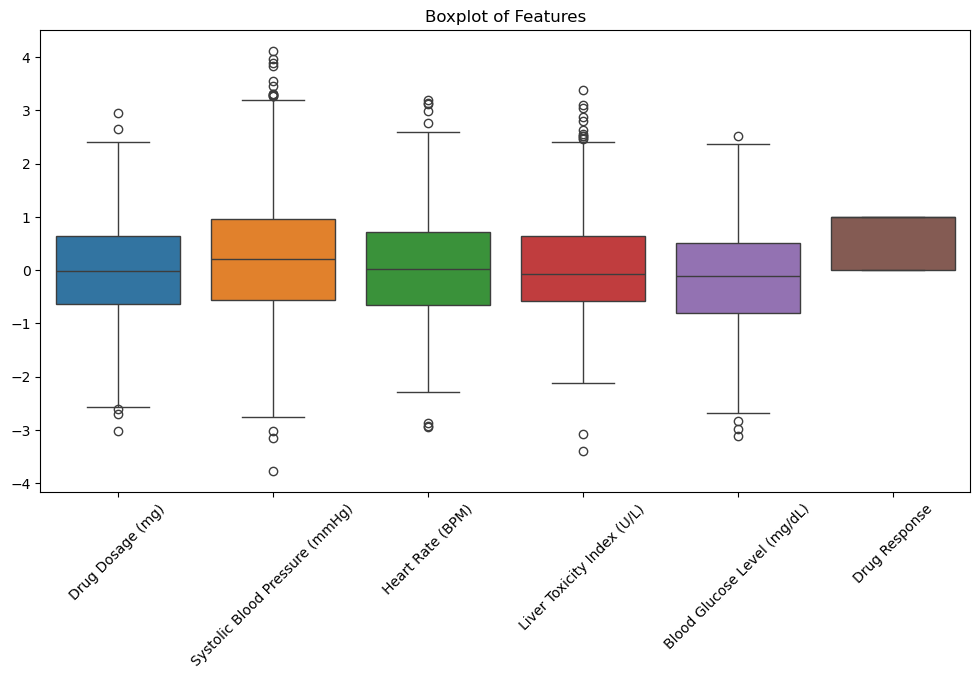

In [7]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

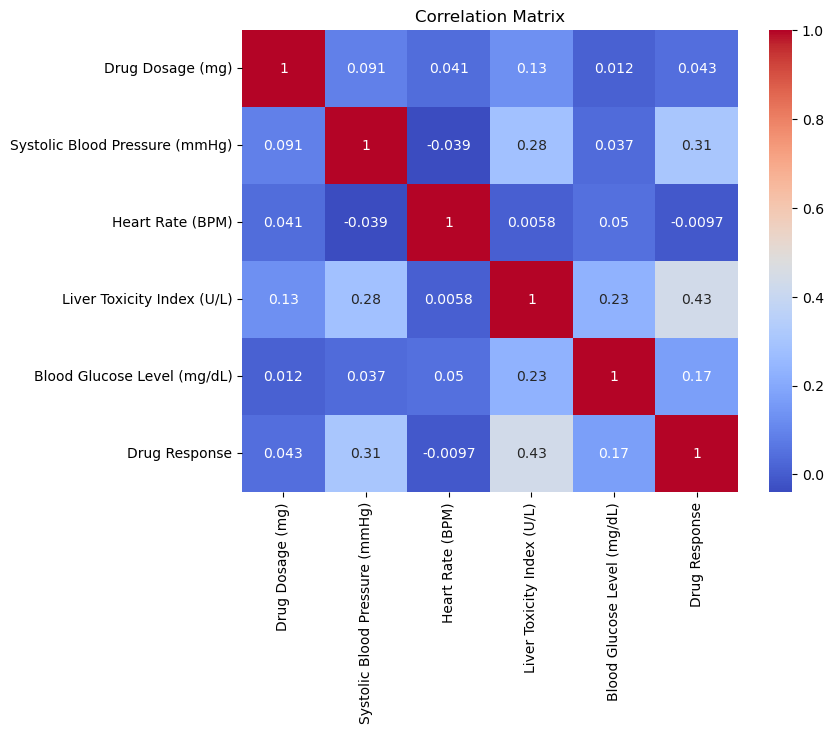

In [8]:
plt.figure(figsize=(8,6))

corr = df.corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

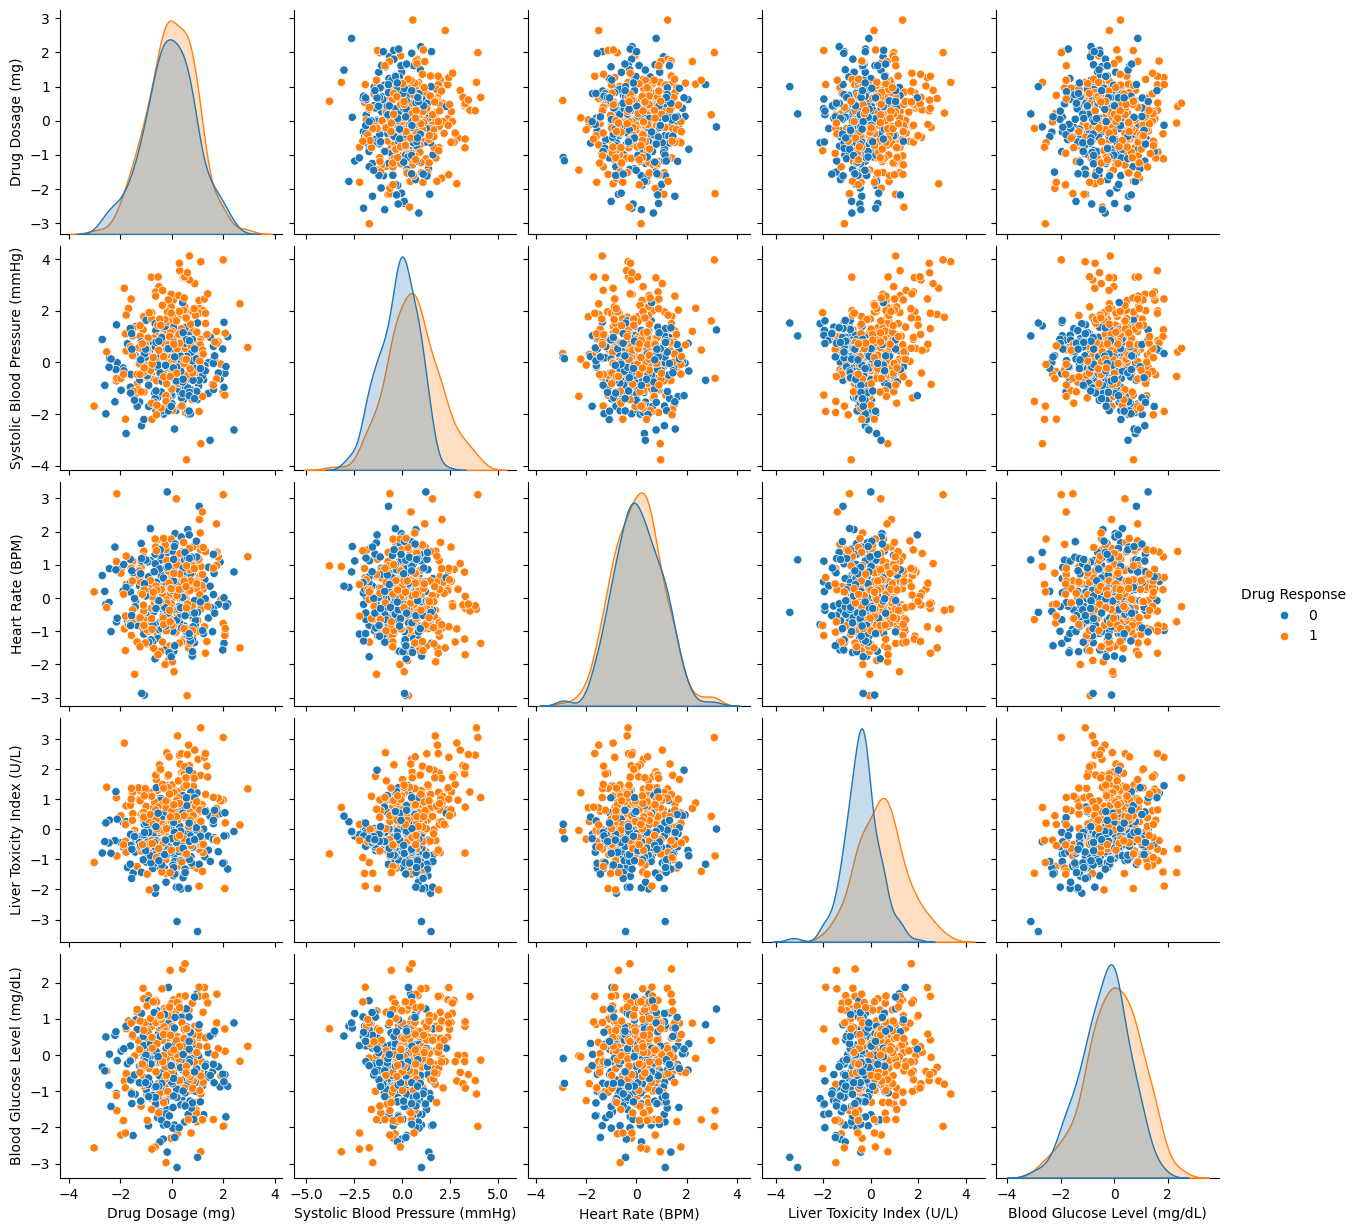

In [9]:
sns.pairplot(df,
             hue='Drug Response')

plt.show()

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Liver Toxicity Index',
    y='Blood Glucose Level',
    hue='Drug Response',
    data=df
)

plt.title("Scatter Plot")
plt.show()

ValueError: Could not interpret value `Liver Toxicity Index` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [11]:
X = df.drop("Drug Response", axis=1)

y = df["Drug Response"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(400, 5)
(100, 5)


In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [14]:
linear_svm = SVC(kernel='linear')

linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)

In [15]:
print("Linear Kernel Results")

print("Accuracy:",
      accuracy_score(y_test,y_pred_linear))

print("Precision:",
      precision_score(y_test,y_pred_linear))

print("Recall:",
      recall_score(y_test,y_pred_linear))

print("F1 Score:",
      f1_score(y_test,y_pred_linear))

Linear Kernel Results
Accuracy: 0.78
Precision: 0.84
Recall: 0.75
F1 Score: 0.7924528301886793


In [17]:
poly_svm = SVC(
    kernel='poly',
    degree=3
)

poly_svm.fit(X_train,y_train)

y_pred_poly = poly_svm.predict(X_test)

In [18]:
print("Polynomial Kernel Results")

print("Accuracy:",
      accuracy_score(y_test,y_pred_poly))

print("Precision:",
      precision_score(y_test,y_pred_poly))

print("Recall:",
      recall_score(y_test,y_pred_poly))

print("F1 Score:",
      f1_score(y_test,y_pred_poly))

Polynomial Kernel Results
Accuracy: 0.71
Precision: 0.8857142857142857
Recall: 0.5535714285714286
F1 Score: 0.6813186813186813


In [19]:
rbf_svm = SVC(kernel='rbf')

rbf_svm.fit(X_train,y_train)

y_pred_rbf = rbf_svm.predict(X_test)

In [20]:
print("RBF Kernel Results")

print("Accuracy:",
      accuracy_score(y_test,y_pred_rbf))

print("Precision:",
      precision_score(y_test,y_pred_rbf))

print("Recall:",
      recall_score(y_test,y_pred_rbf))

print("F1 Score:",
      f1_score(y_test,y_pred_rbf))

RBF Kernel Results
Accuracy: 0.84
Precision: 0.8703703703703703
Recall: 0.8392857142857143
F1 Score: 0.8545454545454545


In [21]:
print(classification_report(
    y_test,
    y_pred_rbf
))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82        44
           1       0.87      0.84      0.85        56

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



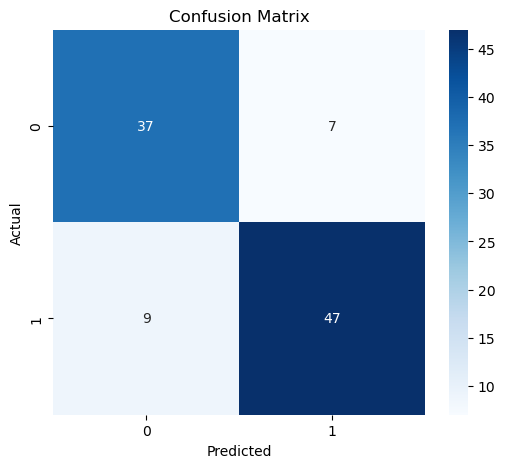

In [22]:
cm = confusion_matrix(
    y_test,
    y_pred_rbf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
param_grid = {
    'C':[0.1,1,10,100],
    'gamma':['scale',0.1,0.01,0.001],
    'kernel':['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 0.1, 0.01, 0.001],
                         'kernel': ['rbf']},
             scoring='accuracy')

In [24]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Accuracy:")
print(grid.best_score_)

Best Parameters:
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

Best Accuracy:
0.7324999999999999


In [25]:
best_svm = grid.best_estimator_

best_svm.fit(X_train,y_train)

y_pred_best = best_svm.predict(X_test)

In [26]:
print("Final Accuracy:",
      accuracy_score(y_test,y_pred_best))

print("Final Precision:",
      precision_score(y_test,y_pred_best))

print("Final Recall:",
      recall_score(y_test,y_pred_best))

print("Final F1 Score:",
      f1_score(y_test,y_pred_best))

Final Accuracy: 0.84
Final Precision: 0.9166666666666666
Final Recall: 0.7857142857142857
Final F1 Score: 0.8461538461538461


In [27]:
results = pd.DataFrame({
    'Kernel':['Linear','Polynomial','RBF'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_linear),
        accuracy_score(y_test,y_pred_poly),
        accuracy_score(y_test,y_pred_rbf)
    ]
})

print(results)

       Kernel  Accuracy
0      Linear      0.78
1  Polynomial      0.71
2         RBF      0.84


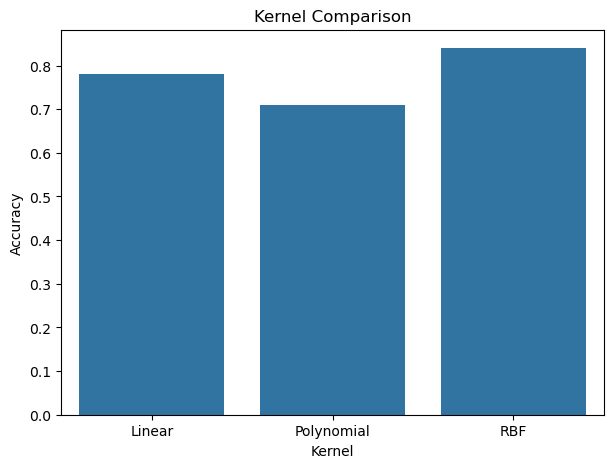

In [29]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='Kernel',
    y='Accuracy',
    data=results
)

plt.title("Kernel Comparison")
plt.show()